# Final Results

In this notebook we will tune hyperparameters on our `DROP_DT_TC_RF_SMOTE` model and test the final result. For convinence here is a snippet of the model defintion from the [modeling_and_feature_eng](modeling_and_feature_eng.ipynb) notebook. We will also redefine the model here in detail.


```python
ImbPipeline([
    ('DT', tf.DewTempSpread('TMP-DEW')),
    ('TC',tf.DatetimeSinCosConverter(monthofyear=True,hourofday=True)),
    ('preprocessor', DROP_TC_DT_preprocessor),
    ('smote', SMOTE(
        sampling_strategy=0.3,
        k_neighbors=5,
        random_state=42
    )),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ))
])

 CalibratedClassifierCV(
        estimator= model,  
        method='isotonic',        
        cv=expanding_cv                     
        )

```







## 1. Imports

In [11]:
## Setup
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import notebook_file_utilities.auto_add_project_root as proroot
import pathlib
import sklearn
from sklearn.base import clone


# Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, GridSearchCV,cross_validate





# sklearn preprocessing
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (OneHotEncoder, 
                                    FunctionTransformer, 
                                    StandardScaler)


# Calibration
from sklearn.calibration import CalibratedClassifierCV


# For reading in modules from src and reading/saving files
project_root = proroot.auto_add_project_root()

import src.modeling.model_summary as mds
from src.modeling.model_summary import ModelingUtilities as ModelU
import src.modeling.train_test_split as tts
# Pipeline

import src.pipeline.transformers as tf

import src.modeling.analysis_utilities as au


sklearn.set_config(transform_output="default")

## 2. Train-Val Data Splits

We will read in the final test data later on in the notebook. 

In [12]:
train_data=pd.read_csv(project_root/pathlib.Path('data/train_val_test_splits/train_data.csv'))
val_data = pd.read_csv(project_root/pathlib.Path('data/train_val_test_splits/val_data.csv'))
train_data['DATE'] = pd.to_datetime(train_data['DATE'])
val_data['DATE'] = pd.to_datetime(val_data['DATE'])
y_train = train_data['TORNADO_OCCURRENCE']
X_train = train_data.drop(columns = ['TORNADO_OCCURRENCE'])

y_val = val_data['TORNADO_OCCURRENCE']
X_val = val_data.drop(columns = ['TORNADO_OCCURRENCE'])

expanding_cv=tts.YearlyTemporalWindowSplit(start_year =2002,end_year = 2017, val_window_size=2)

## 3. Model Definition

The code below defines our `TC_HR_RandomForest_Balanced` model.

In [ ]:
#=========================================================================
# FEATURE CATEGORIES FOR COLUMN TRANSFORMER PREPROCESSING
#=========================================================================

feat_engin_time_features = ['sin_monthofyear',
       'cos_monthofyear', 'sin_hourofday',
       'cos_hourofday']


feat_engin_temp_dew =['TMP-DEW']

feat_engin_rolling_average = ['PER_HOUR_DEW_dew_point','PER_HOUR_TMP_air_temperature','PER_HOUR_SLP_sea_level_pressure']

turn_to_binary_features = [
    'CIG_cavok_code', 'VIS_variability_code'
]

nominal_features = [
    'WND_type_code', 
]

numeric_features = [
    'WND_direction_angle', 'WND_speed_rate',
    'CIG_ceiling_height', 'VIS_distance',
    'TMP_air_temperature', 'DEW_dew_point',
    'SLP_sea_level_pressure'
]



binary_features = ['WND_direction_angle_variable_wind_direction_flag']

datetime_features=['DATE']


#=========================================================================
# BINARY ENCODING FUNCTION
#=========================================================================


def encode_binary(X):
    """Map binary codes to 1, 0."""
    mappings = {
        'CIG_cavok_code': {'N': 0, 'Y': 1},
        'VIS_variability_code': {'N': 0, 'V': 1}
    }
    X_copy = X.copy()
    for col in X_copy.columns:
        if col in mappings:
            X_copy[col] = X_copy[col].map(mappings[col]).fillna(-1).astype(int)
    return X_copy


#=========================================================================
# PIPELINES FOR PREPROCESSING COLUMN TRANSFORMER
#=========================================================================

feat_engin_numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median',missing_values=np.nan)),
    ('scale', StandardScaler())
])


numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median',missing_values=np.nan)),
    ('scale', StandardScaler())
])


turn_to_binary_pipeline = Pipeline(
    [
        ('binary', FunctionTransformer(encode_binary, feature_names_out='one-to-one'))
    ]
    )

nominal_features_pipeline = Pipeline(
    [
        ('nominal', OneHotEncoder(drop='first', handle_unknown='ignore',sparse_output=False))
    ]
)

#=========================================================================
# PREPROCESSING COLUMN TRANSFORMER

#=========================================================================
# PREPROCESSING COLUMN TRANSFORMER ADDITIONAL CIG DROP
#=========================================================================

#TC= time-conversion
#DT= dew temp spread
#HR = hourly rates
#OG = original











In [ ]:
models = {}

DROP_DT_TC_RF_SMOTE = joblib.load(project_root/'models/DROP_DT_TC_RF_SMOTE.joblib')

models['DROP_DT_TC_RF_SMOTE'] = DROP_DT_TC_RF_SMOTE

DROP_DT_TC_RF_SMOTE.get_params




<bound method BaseEstimator.get_params of CalibratedClassifierCV(cv=YearlyTemporalWindowSplit(end_year=2017, start_year=2001, val_window_size=2),
                       estimator=Pipeline(steps=[('DT',
                                                  DewTempSpread(new_col='TMP-DEW')),
                                                 ('TC',
                                                  DatetimeSinCosConverter()),
                                                 ('preprocessor',
                                                  ColumnTransformer(transformers=[('feat_engin_temp_dew',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median')),
                                                                                                   ('scale',
                                                    

## 4. Cross Validation and Hyperparameter Tuning

### 4.1 Cross Validation Folds

Our cross validation strategy consists of using our custom splitter `YearlyTemporalWindowSplit()`, which can be found in [src/modeling/train_test_split.py](../src/modeling/train_test_split.py). `YearlyTemporalWindowSplit()` creates our cv folds as follows:

Fold 1:  Train [2000]      → Val [2001-2002]
Fold 2:  Train [2000-2003] → Val [2003-2004]
...
Fold 8: Train [2000-2015] → Val [2016-2017]

We do this for the following reasons:

1. **Data Leakage Prevention:** Our folds do not leak temporal data from their respective validation and training sets.

2. **Validation Consistency:** The folds have the same number of validation years. If number of validation years decreased or increased in size, we might receive a distorted view when we analyze overfitting.

3. **Real-World Consistency:** We **do not** ensure that tornado frequencies are consistent across our validation folds. This is inconsistent with reality as tornadic activity varies from year to year. This allows us to measure how our model handles temporal inconsistencies in torando occurrences.

4. **Expanding training windows:** Progressive increases in training data simulate the realistic scenario of deploying models with accumulating historical data, helping us understand how performance and overfitting scales with data availability.

The function call below, `tts.temporal_cross_validation(X_train,n_splits=4)`,  splits our training data as described above. See [train_test_split.py](../src/modeling/train_test_split.py) for source code.

### 4.2 GridCVSearch

Recall that our current pre-callibrated is:

```python
ImbPipeline([
    ('DT', tf.DewTempSpread('TMP-DEW')),
    ('TC',tf.DatetimeSinCosConverter(monthofyear=True,hourofday=True)),
    ('preprocessor', DROP_TC_DT_preprocessor),
    ('smote', SMOTE(
        sampling_strategy=0.3,
        k_neighbors=5,
        random_state=42
    )),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ))
])

```

**GridSearchCV Goal:** control overfitting while maintaining **average_precision** performance. We will also use our cross-validation folds defined above.

In [46]:


first_param_grid = {
    'estimator__smote__sampling_strategy': [0.2, 0.3,0.5],
    'estimator__smote__k_neighbors': [5,7,10]
}

first_grid_search = GridSearchCV(
    estimator=DROP_DT_TC_RF_SMOTE,
    param_grid=first_param_grid,
    cv=expanding_cv,
    scoring='average_precision',
    n_jobs=-1,
    verbose=2
)

first_grid_search.fit(X_train, y_train)



Fitting 8 folds for each of 9 candidates, totalling 72 fits
[CV] END estimator__smote__k_neighbors=5, estimator__smote__sampling_strategy=0.2; total time=   3.3s
[CV] END estimator__smote__k_neighbors=5, estimator__smote__sampling_strategy=0.3; total time=   3.4s
[CV] END estimator__smote__k_neighbors=5, estimator__smote__sampling_strategy=0.2; total time=  10.0s
[CV] END estimator__smote__k_neighbors=5, estimator__smote__sampling_strategy=0.3; total time=  11.6s
[CV] END estimator__smote__k_neighbors=5, estimator__smote__sampling_strategy=0.2; total time=  26.1s
[CV] END estimator__smote__k_neighbors=5, estimator__smote__sampling_strategy=0.3; total time=  34.0s
[CV] END estimator__smote__k_neighbors=5, estimator__smote__sampling_strategy=0.2; total time=  52.2s
[CV] END estimator__smote__k_neighbors=5, estimator__smote__sampling_strategy=0.5; total time=   5.0s
[CV] END estimator__smote__k_neighbors=5, estimator__smote__sampling_strategy=0.3; total time= 1.1min
[CV] END estimator__sm

,estimator,CalibratedCla...od='isotonic')
,param_grid,"{'estimator__smote__k_neighbors': [5, 7, ...], 'estimator__smote__sampling_strategy': [0.2, 0.3, ...]}"
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,YearlyTempora...window_size=2)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,new_col,'TMP-DEW'


#### 4.2.1 GridCVSearch Results

In [47]:

first_grid_search_results = pd.DataFrame(first_grid_search.cv_results_)


save_to = pathlib.Path("results/cv_parameter_search/random_forest/uncal_first_grid_search_results.csv")
first_grid_search_results.to_csv(project_root/save_to)


display(first_grid_search_results.sort_values(by='rank_test_score', ascending=True) )




,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_estimator__smote__k_neighbors,param_estimator__smote__sampling_strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,mean_test_score,std_test_score,rank_test_score
8,103.018558,66.612083,0.962354,0.482204,10,0.5,"{'estimator__smote__k_neighbors': 10, 'estimat...",0.001449,0.015133,0.003358,0.016296,0.309814,0.060914,0.115248,0.062298,0.073064,0.096605,1
1,105.370498,93.941716,2.047774,1.067877,5,0.3,"{'estimator__smote__k_neighbors': 5, 'estimato...",0.001408,0.011248,0.003817,0.018006,0.278643,0.049314,0.141372,0.052798,0.069576,0.089853,2
7,100.461314,81.184330,1.515175,0.636857,10,0.3,"{'estimator__smote__k_neighbors': 10, 'estimat...",0.001802,0.014926,0.003334,0.019433,0.297840,0.049064,0.127206,0.039488,0.069137,0.094361,3
0,88.072407,79.470842,1.626808,0.887051,5,0.2,"{'estimator__smote__k_neighbors': 5, 'estimato...",0.001311,0.012511,0.003216,0.018696,0.277385,0.052010,0.124736,0.056850,0.068339,0.087746,4
2,156.137683,140.658295,1.781618,0.879681,5,0.5,"{'estimator__smote__k_neighbors': 5, 'estimato...",0.001409,0.012826,0.003938,0.015749,0.268000,0.053645,0.119229,0.065315,0.067514,0.084519,5
3,95.496706,82.979550,2.120008,1.249847,7,0.2,"{'estimator__smote__k_neighbors': 7, 'estimato...",0.002149,0.012560,0.003439,0.022400,0.261449,0.049788,0.114379,0.062508,0.066084,0.081825,6
4,115.318119,99.274324,1.894751,0.891769,7,0.3,"{'estimator__smote__k_neighbors': 7, 'estimato...",0.001381,0.012804,0.003525,0.018258,0.267848,0.055761,0.111198,0.039916,0.063837,0.084203,7
6,90.147759,76.684485,1.796491,0.803900,10,0.2,"{'estimator__smote__k_neighbors': 10, 'estimat...",0.000956,0.014372,0.003218,0.021374,0.255480,0.053258,0.117389,0.040706,0.063344,0.080714,8
5,154.664398,133.908714,2.008208,0.923376,7,0.5,"{'estimator__smote__k_neighbors': 7, 'estimato...",0.001157,0.013224,0.003736,0.015543,0.245182,0.048071,0.113951,0.057110,0.062247,0.077545,9


In [62]:
first_grid_search_models= first_grid_search_results['params'].to_dict()
baseline_rf= DROP_DT_TC_RF_SMOTE
first_grid_search_models_to_cal = {}
for key,val in first_grid_search_models.items():
    # Clone first, then set params
    cloned_model = clone(baseline_rf)
    first_grid_search_models_to_cal[f'rf_model_{key}']=cloned_model.set_params(**val)
    

# check that number of keys is the same number as reasonable numbers
assert(len(list(first_grid_search_models_to_cal.keys())) == len(first_grid_search_models))


data_dict = {'train': {'X':X_train,'y':y_train},
                'validation': {'X':X_val,'y':y_val}}
first_grid_search_cal_metrics=mds.train_val_model_metrics_df(models_dict=first_grid_search_models_to_cal,data_dict=data_dict)
save_to = pathlib.Path(project_root/"results/cv_parameter_search/random_forest/first_grid_search_cal_model_metrics.csv")
first_grid_search_cal_metrics.to_csv(save_to)


first_grid_search_cal_metrics['train_val_ap_ratio']=first_grid_search_cal_metrics['train_avg_precision']/first_grid_search_cal_metrics['validation_avg_precision']
first_grid_search_cal_metrics['train_val_f2_ratio']=first_grid_search_cal_metrics['train_F2']/first_grid_search_cal_metrics['validation_F2']

display(first_grid_search_cal_metrics.sort_values(by='validation_avg_precision',ascending=False))
print("="*80)
print("\n Our best model")
best_model_row = first_grid_search_cal_metrics.sort_values(by='validation_avg_precision',ascending=False).iloc[0]
best_model_name = best_model_row['Model']
best_model = first_grid_search_models_to_cal[best_model_name]

display(best_model_row)



Fitting model rf_model_0
Fitting model rf_model_1
Fitting model rf_model_2
Fitting model rf_model_3
Fitting model rf_model_4
Fitting model rf_model_5
Fitting model rf_model_6
Fitting model rf_model_7
Fitting model rf_model_8


,Model,train_avg_precision,validation_avg_precision,train_F2,validation_F2,train_Recall,validation_Recall,train_Precision,validation_Precision,train_roc_auc,validation_roc_auc,train_brier_score,validation_brier_score,Parameters,train_val_ap_ratio,train_val_f2_ratio
4,rf_model_4,0.351493,0.079790,0.424096,0.091408,0.466844,0.085470,0.310406,0.126582,0.986940,0.909424,0.001308,0.002129,{'cv': YearlyTemporalWindowSplit(end_year=2017...,4.405233,4.639614
1,rf_model_1,0.347363,0.071004,0.446447,0.082372,0.571618,0.085470,0.237990,0.071942,0.988056,0.898138,0.001315,0.002131,{'cv': YearlyTemporalWindowSplit(end_year=2017...,4.892162,5.419867
5,rf_model_5,0.309028,0.070103,0.421538,0.081037,0.545093,0.085470,0.221087,0.067114,0.986774,0.910585,0.001317,0.002126,{'cv': YearlyTemporalWindowSplit(end_year=2017...,4.408211,5.201785
6,rf_model_6,0.372352,0.067521,0.443169,0.088968,0.511936,0.085470,0.288275,0.106383,0.987885,0.911364,0.001280,0.002125,{'cv': YearlyTemporalWindowSplit(end_year=2017...,5.514606,4.981217
7,rf_model_7,0.354889,0.061824,0.421053,0.098039,0.530504,0.102564,0.230681,0.083333,0.987839,0.909988,0.001301,0.002128,{'cv': YearlyTemporalWindowSplit(end_year=2017...,5.740268,4.294737
8,rf_model_8,0.292806,0.058234,0.398900,0.088889,0.538462,0.102564,0.195851,0.057971,0.986552,0.899025,0.001318,0.002125,{'cv': YearlyTemporalWindowSplit(end_year=2017...,5.028052,4.487620
2,rf_model_2,0.312456,0.055270,0.393642,0.082508,0.489390,0.085470,0.220826,0.072464,0.986942,0.899478,0.001318,0.002131,{'cv': YearlyTemporalWindowSplit(end_year=2017...,5.653247,4.770941
3,rf_model_3,0.383892,0.053292,0.448508,0.087302,0.582228,0.094017,0.233759,0.067901,0.988108,0.914858,0.001288,0.002134,{'cv': YearlyTemporalWindowSplit(end_year=2017...,7.203496,5.137460
0,rf_model_0,0.384559,0.046658,0.444075,0.089767,0.496021,0.085470,0.312971,0.112360,0.987795,0.897210,0.001283,0.002141,{'cv': YearlyTemporalWindowSplit(end_year=2017...,8.242022,4.946996



 Our best model


Model                                                              rf_model_4
train_avg_precision                                                  0.351493
validation_avg_precision                                              0.07979
train_F2                                                             0.424096
validation_F2                                                        0.091408
train_Recall                                                         0.466844
validation_Recall                                                     0.08547
train_Precision                                                      0.310406
validation_Precision                                                 0.126582
train_roc_auc                                                         0.98694
validation_roc_auc                                                   0.909424
train_brier_score                                                    0.001308
validation_brier_score                                          


Here we see that `rf_model_4` has a train_val_ap_ratio of 4.405222 --  still a moderate overfitting ratio. However, it is an improvement from our train_val_ap_ratio of 4.893455 for `DROP_DT_TC_RF_SMOTE`; moreover, `rf_model_4` has a validation AP increase from the validation AP of `DROP_DT_TC_RF_SMOTE`. We then choose `rf_model_4` as a final candidate over `DROP_DT_TC_RF_SMOTE`. Below we save `rf_model_4` as final_candidate_1.

In [67]:
# Save rf_model_4
new_params = best_model_row['Parameters']
baseline_rf = DROP_DT_TC_RF_SMOTE
cloned_model = clone(baseline_rf)
final_candidate_1 = cloned_model.set_params(**new_params)



In [ ]:


second_param_grid = {
    'estimator__classifier__n_estimators': [50 ,100, 300, 400],
    'estimator__classifier__max_depth': [2,5,7,10],
    'estimator__classifier__max_features': ['sqrt'],
    'estimator__classifier__min_samples_leaf':[10,20,100,300],
    'estimator__classifier__min_samples_split':[30,50,200,500],
    'estimator__smote__sampling_strategy': [0.3],
    'estimator__smote__k_neighbors': [7]
    
}

second_grid_search = GridSearchCV(
    estimator=DROP_DT_TC_RF_SMOTE,
    param_grid=second_param_grid,
    cv=expanding_cv,
    scoring='average_precision',
    n_jobs=-1,
    verbose=2
)

second_grid_search.fit(X_train, y_train)

Fitting 8 folds for each of 256 candidates, totalling 2048 fits
[CV] END estimator__classifier__max_depth=2, estimator__classifier__max_features=sqrt, estimator__classifier__min_samples_leaf=10, estimator__classifier__min_samples_split=30, estimator__classifier__n_estimators=50, estimator__smote__k_neighbors=7, estimator__smote__sampling_strategy=0.3; total time=   1.0s
[CV] END estimator__classifier__max_depth=2, estimator__classifier__max_features=sqrt, estimator__classifier__min_samples_leaf=10, estimator__classifier__min_samples_split=30, estimator__classifier__n_estimators=100, estimator__smote__k_neighbors=7, estimator__smote__sampling_strategy=0.3; total time=   1.3s
[CV] END estimator__classifier__max_depth=2, estimator__classifier__max_features=sqrt, estimator__classifier__min_samples_leaf=10, estimator__classifier__min_samples_split=30, estimator__classifier__n_estimators=50, estimator__smote__k_neighbors=7, estimator__smote__sampling_strategy=0.3; total time=   3.2s
[CV] END

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END estimator__classifier__max_depth=2, estimator__classifier__max_features=sqrt, estimator__classifier__min_samples_leaf=100, estimator__classifier__min_samples_split=500, estimator__classifier__n_estimators=400, estimator__smote__k_neighbors=7, estimator__smote__sampling_strategy=0.3; total time= 5.4min
[CV] END estimator__classifier__max_depth=2, estimator__classifier__max_features=sqrt, estimator__classifier__min_samples_leaf=300, estimator__classifier__min_samples_split=30, estimator__classifier__n_estimators=300, estimator__smote__k_neighbors=7, estimator__smote__sampling_strategy=0.3; total time= 2.4min
[CV] END estimator__classifier__max_depth=2, estimator__classifier__max_features=sqrt, estimator__classifier__min_samples_leaf=300, estimator__classifier__min_samples_split=50, estimator__classifier__n_estimators=50, estimator__smote__k_neighbors=7, estimator__smote__sampling_strategy=0.3; total time=  24.4s
[CV] END estimator__classifier__max_depth=2, estimator__classifier_

,estimator,CalibratedCla...od='isotonic')
,param_grid,"{'estimator__classifier__max_depth': [2, 5, ...], 'estimator__classifier__max_features': ['sqrt'], 'estimator__classifier__min_samples_leaf': [10, 20, ...], 'estimator__classifier__min_samples_split': [30, 50, ...], ...}"
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,YearlyTempora...window_size=2)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,new_col,'TMP-DEW'


In [58]:

second_grid_search_results = pd.DataFrame(second_grid_search.cv_results_)


save_to = pathlib.Path("results/cv_parameter_search/random_forest/second_grid_search_results.csv")
second_grid_search_results.to_csv(project_root/save_to)

pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', None)
display(second_grid_search_results.sort_values(by='rank_test_score', ascending=True) )


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_estimator__classifier__max_depth,param_estimator__classifier__max_features,param_estimator__classifier__min_samples_leaf,param_estimator__classifier__min_samples_split,param_estimator__classifier__n_estimators,param_estimator__smote__k_neighbors,param_estimator__smote__sampling_strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,mean_test_score,std_test_score,rank_test_score
127,266.749960,220.203520,4.101090,2.175206,5,sqrt,300,500,400,7,0.3,"{'estimator__classifier__max_depth': 5, 'estim...",0.002541,0.015813,0.005021,0.022742,0.336835,0.065156,0.138787,0.064469,0.081421,0.105408,1
115,269.417168,224.599338,3.949461,2.507567,5,sqrt,300,30,400,7,0.3,"{'estimator__classifier__max_depth': 5, 'estim...",0.002541,0.015813,0.005021,0.022742,0.336835,0.065156,0.138787,0.064469,0.081421,0.105408,1
119,265.087881,229.731269,3.413153,1.492515,5,sqrt,300,50,400,7,0.3,"{'estimator__classifier__max_depth': 5, 'estim...",0.002541,0.015813,0.005021,0.022742,0.336835,0.065156,0.138787,0.064469,0.081421,0.105408,1
123,263.472307,216.844489,3.836262,2.253266,5,sqrt,300,200,400,7,0.3,"{'estimator__classifier__max_depth': 5, 'estim...",0.002541,0.015813,0.005021,0.022742,0.336835,0.065156,0.138787,0.064469,0.081421,0.105408,1
182,254.942090,217.623740,3.108407,1.867994,7,sqrt,300,50,300,7,0.3,"{'estimator__classifier__max_depth': 7, 'estim...",0.002456,0.017781,0.004422,0.024205,0.324778,0.064098,0.139118,0.064772,0.080204,0.101615,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36,29.057433,23.131112,2.144564,1.121842,2,sqrt,100,50,50,7,0.3,"{'estimator__classifier__max_depth': 2, 'estim...",0.001161,0.010889,0.003599,0.043526,0.154694,0.066239,0.044705,0.031324,0.044517,0.046731,252
32,29.378398,24.551961,1.727522,0.893346,2,sqrt,100,30,50,7,0.3,"{'estimator__classifier__max_depth': 2, 'estim...",0.001161,0.010892,0.003598,0.043519,0.154694,0.066229,0.044705,0.031318,0.044515,0.046731,253
60,32.466798,22.145077,2.109471,0.931185,2,sqrt,300,500,50,7,0.3,"{'estimator__classifier__max_depth': 2, 'estim...",0.001178,0.010839,0.003604,0.043522,0.154831,0.066234,0.044719,0.030729,0.044457,0.046795,254
24,30.225902,22.660790,1.818673,0.979073,2,sqrt,20,200,50,7,0.3,"{'estimator__classifier__max_depth': 2, 'estim...",0.001163,0.010867,0.003600,0.043518,0.154835,0.066239,0.044603,0.030729,0.044444,0.046796,255


From our CVGridSearch results, we see that  our `min_samples_split` parameters were too close together, but that a `min_sample_leaf` of 300 appears to be optimal amongst our top performers when `max_depth`=5,7 and `n_estimators` = 300,400. Moreover, our top performers have a better mean_test_score that is .03 higher than our best performers in our first grid search, while maintaining a similar mean_test_std. 

As there are too many models to test, and quite a few have the same rank, we perform a final grid search before we apply each results parameters to our model (as we did after the first grid search). In this one, we will focus on varying min_split_sample.





In [57]:
final_param_grid = {
    'estimator__classifier__n_estimators': [300, 400], # top performers
    'estimator__classifier__max_depth': [5,7], # top performers
    'estimator__classifier__max_features': ['sqrt'],
    'estimator__classifier__min_samples_leaf':[300], # top performer
    'estimator__classifier__min_samples_split':[500,1000,1500], #30,50,200,500 little variance so our baseline will be 500
    'estimator__smote__sampling_strategy': [0.3],
    'estimator__smote__k_neighbors': [7]
    
}

final_grid_search = GridSearchCV(
    estimator=DROP_DT_TC_RF_SMOTE,
    param_grid=final_param_grid,
    cv=expanding_cv,
    scoring='average_precision',
    n_jobs=-1,
    verbose=2
)

final_grid_search.fit(X_train, y_train)

Fitting 8 folds for each of 12 candidates, totalling 96 fits
[CV] END estimator__classifier__max_depth=5, estimator__classifier__max_features=sqrt, estimator__classifier__min_samples_leaf=300, estimator__classifier__min_samples_split=500, estimator__classifier__n_estimators=300, estimator__smote__k_neighbors=7, estimator__smote__sampling_strategy=0.3; total time=   5.9s
[CV] END estimator__classifier__max_depth=5, estimator__classifier__max_features=sqrt, estimator__classifier__min_samples_leaf=300, estimator__classifier__min_samples_split=500, estimator__classifier__n_estimators=400, estimator__smote__k_neighbors=7, estimator__smote__sampling_strategy=0.3; total time=   8.4s
[CV] END estimator__classifier__max_depth=5, estimator__classifier__max_features=sqrt, estimator__classifier__min_samples_leaf=300, estimator__classifier__min_samples_split=500, estimator__classifier__n_estimators=300, estimator__smote__k_neighbors=7, estimator__smote__sampling_strategy=0.3; total time=  26.8s
[CV

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END estimator__classifier__max_depth=7, estimator__classifier__max_features=sqrt, estimator__classifier__min_samples_leaf=300, estimator__classifier__min_samples_split=1500, estimator__classifier__n_estimators=300, estimator__smote__k_neighbors=7, estimator__smote__sampling_strategy=0.3; total time=  34.3s
[CV] END estimator__classifier__max_depth=7, estimator__classifier__max_features=sqrt, estimator__classifier__min_samples_leaf=300, estimator__classifier__min_samples_split=500, estimator__classifier__n_estimators=400, estimator__smote__k_neighbors=7, estimator__smote__sampling_strategy=0.3; total time=10.9min
[CV] END estimator__classifier__max_depth=7, estimator__classifier__max_features=sqrt, estimator__classifier__min_samples_leaf=300, estimator__classifier__min_samples_split=1500, estimator__classifier__n_estimators=300, estimator__smote__k_neighbors=7, estimator__smote__sampling_strategy=0.3; total time= 1.5min
[CV] END estimator__classifier__max_depth=7, estimator__classi

,estimator,CalibratedCla...od='isotonic')
,param_grid,"{'estimator__classifier__max_depth': [5, 7], 'estimator__classifier__max_features': ['sqrt'], 'estimator__classifier__min_samples_leaf': [300], 'estimator__classifier__min_samples_split': [500, 1000, ...], ...}"
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,YearlyTempora...window_size=2)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,new_col,'TMP-DEW'


In [59]:


final_grid_search_results = pd.DataFrame(final_grid_search.cv_results_)


save_to = pathlib.Path("results/cv_parameter_search/random_forest/final_grid_search_results.csv")
final_grid_search_results.to_csv(project_root/save_to)

pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', None)
display(final_grid_search_results.sort_values(by='rank_test_score', ascending=True) )


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_estimator__classifier__max_depth,param_estimator__classifier__max_features,param_estimator__classifier__min_samples_leaf,param_estimator__classifier__min_samples_split,param_estimator__classifier__n_estimators,param_estimator__smote__k_neighbors,param_estimator__smote__sampling_strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,mean_test_score,std_test_score,rank_test_score
1,280.847420,230.165384,3.929830,1.997185,5,sqrt,300,500,400,7,0.3,"{'estimator__classifier__max_depth': 5, 'estim...",0.002541,0.015813,0.005021,0.022742,0.336835,0.065156,0.138787,0.064469,0.081421,0.105408,1
6,262.748803,229.143796,3.507975,1.551818,7,sqrt,300,500,300,7,0.3,"{'estimator__classifier__max_depth': 7, 'estim...",0.002456,0.017781,0.004422,0.024205,0.324778,0.064098,0.139118,0.064772,0.080204,0.101615,2
8,254.909923,211.518543,3.484162,1.749494,7,sqrt,300,1000,300,7,0.3,"{'estimator__classifier__max_depth': 7, 'estim...",0.002224,0.017716,0.003946,0.022589,0.339179,0.061785,0.134093,0.058657,0.080024,0.106004,3
7,343.740221,297.604907,4.312407,2.549253,7,sqrt,300,500,400,7,0.3,"{'estimator__classifier__max_depth': 7, 'estim...",0.002592,0.018051,0.004274,0.025588,0.317722,0.063045,0.141323,0.061381,0.079247,0.099641,4
9,330.523111,265.167536,3.370836,1.407002,7,sqrt,300,1000,400,7,0.3,"{'estimator__classifier__max_depth': 7, 'estim...",0.002298,0.017631,0.003965,0.022749,0.328674,0.057795,0.137951,0.061150,0.079027,0.103092,5
4,218.122752,187.325094,2.832668,1.186341,5,sqrt,300,1500,300,7,0.3,"{'estimator__classifier__max_depth': 5, 'estim...",0.002623,0.016510,0.004385,0.020201,0.319500,0.069334,0.144362,0.053147,0.078758,0.101018,6
10,246.362113,193.109075,2.674611,1.192972,7,sqrt,300,1500,300,7,0.3,"{'estimator__classifier__max_depth': 7, 'estim...",0.002216,0.017028,0.003969,0.023398,0.322930,0.059123,0.131499,0.062201,0.077795,0.100860,7
5,292.555955,248.133036,3.834940,1.909972,5,sqrt,300,1500,400,7,0.3,"{'estimator__classifier__max_depth': 5, 'estim...",0.002238,0.017367,0.004464,0.021180,0.304836,0.066609,0.128938,0.073973,0.077450,0.095030,8
0,213.705751,181.651393,2.811014,1.410511,5,sqrt,300,500,300,7,0.3,"{'estimator__classifier__max_depth': 5, 'estim...",0.002327,0.015908,0.005059,0.022538,0.300633,0.066855,0.132395,0.060616,0.075791,0.094134,9
3,276.624134,229.722895,4.186097,2.668929,5,sqrt,300,1000,400,7,0.3,"{'estimator__classifier__max_depth': 5, 'estim...",0.002421,0.017396,0.004541,0.021071,0.294190,0.069527,0.120813,0.066114,0.074509,0.091316,10


In [146]:
final_grid_search_models= final_grid_search_results['params'].to_dict()
baseline_rf= DROP_DT_TC_RF_SMOTE
final_grid_search_models_to_cal = {}
for key,val in final_grid_search_models.items():
    # Clone first, then set params
    cloned_model = clone(baseline_rf)
    final_grid_search_models_to_cal[f'rf_model_{key}']=cloned_model.set_params(**val)
    

# check 
assert(len(list(final_grid_search_models_to_cal.keys())) == len(final_grid_search_models))


data_dict = {'train': {'X':X_train,'y':y_train},
                'validation': {'X':X_val,'y':y_val}}
final_grid_search_cal_metrics=mds.train_val_model_metrics_df(models_dict=final_grid_search_models_to_cal,data_dict=data_dict)
save_to = pathlib.Path(project_root/"results/cv_parameter_search/random_forest/final_grid_search_cal_model_metrics.csv")
final_grid_search_cal_metrics.to_csv(save_to)


final_grid_search_cal_metrics['train_val_ap_ratio']=final_grid_search_cal_metrics['train_avg_precision']/final_grid_search_cal_metrics['validation_avg_precision']
final_grid_search_cal_metrics['train_val_f2_ratio']=final_grid_search_cal_metrics['train_F2']/final_grid_search_cal_metrics['validation_F2']

display(final_grid_search_cal_metrics.sort_values(by='validation_avg_precision',ascending=False))





Fitting model rf_model_0
Fitting model rf_model_1
Fitting model rf_model_2
Fitting model rf_model_3
Fitting model rf_model_4
Fitting model rf_model_5
Fitting model rf_model_6
Fitting model rf_model_7
Fitting model rf_model_8
Fitting model rf_model_9
Fitting model rf_model_10
Fitting model rf_model_11


,Model,train_avg_precision,validation_avg_precision,train_F2,validation_F2,train_Recall,validation_Recall,train_Precision,validation_Precision,train_roc_auc,validation_roc_auc,train_brier_score,validation_brier_score,Parameters,train_val_ap_ratio,train_val_f2_ratio
11,rf_model_11,0.202660,0.054094,0.310069,0.087580,0.391247,0.094017,0.169443,0.068750,0.981035,0.923537,0.001355,0.002132,{'cv': YearlyTemporalWindowSplit(end_year=2017...,3.746445,3.540428
10,rf_model_10,0.203920,0.053119,0.310124,0.085404,0.411141,0.094017,0.156408,0.062500,0.981091,0.924898,0.001358,0.002135,{'cv': YearlyTemporalWindowSplit(end_year=2017...,3.838942,3.631271
9,rf_model_9,0.209641,0.051159,0.310540,0.084746,0.407162,0.094017,0.159315,0.060773,0.981417,0.926900,0.001353,0.002133,{'cv': YearlyTemporalWindowSplit(end_year=2017...,4.097795,3.664374
7,rf_model_7,0.213788,0.051108,0.319595,0.083714,0.444297,0.094017,0.150562,0.058201,0.981729,0.927645,0.001353,0.002133,{'cv': YearlyTemporalWindowSplit(end_year=2017...,4.183111,3.817713
8,rf_model_8,0.212134,0.048859,0.312276,0.086331,0.462865,0.102564,0.135692,0.052863,0.981486,0.926742,0.001354,0.002134,{'cv': YearlyTemporalWindowSplit(end_year=2017...,4.341725,3.617201
6,rf_model_6,0.216361,0.047897,0.315060,0.084615,0.428382,0.094017,0.153081,0.060440,0.981551,0.928637,0.001355,0.002135,{'cv': YearlyTemporalWindowSplit(end_year=2017...,4.517162,3.723442
5,rf_model_5,0.164905,0.033959,0.266198,0.090610,0.311671,0.094017,0.168097,0.079137,0.972166,0.927058,0.001375,0.002144,{'cv': YearlyTemporalWindowSplit(end_year=2017...,4.856031,2.937863
3,rf_model_3,0.162895,0.033222,0.265356,0.081744,0.404509,0.102564,0.111681,0.045113,0.972521,0.926659,0.001373,0.002144,{'cv': YearlyTemporalWindowSplit(end_year=2017...,4.903281,3.246186
2,rf_model_2,0.162036,0.032609,0.259930,0.084507,0.376658,0.102564,0.116060,0.049587,0.972053,0.926909,0.001377,0.002145,{'cv': YearlyTemporalWindowSplit(end_year=2017...,4.969010,3.075844
1,rf_model_1,0.162489,0.032215,0.272749,0.076014,0.307692,0.076923,0.187551,0.072581,0.972673,0.927984,0.001372,0.002145,{'cv': YearlyTemporalWindowSplit(end_year=2017...,5.043831,3.588160


In [61]:
print("="*80)
print("\n Our best model")
best_model_row = final_grid_search_cal_metrics.sort_values(by='validation_avg_precision',ascending=False).iloc[0]
best_model_name = best_model_row['Model']
best_model = final_grid_search_models_to_cal[best_model_name]

display(best_model_row)


 Our best model


Model                                                             rf_model_11
train_avg_precision                                                  0.202708
validation_avg_precision                                             0.054094
train_F2                                                             0.310069
validation_F2                                                         0.08758
train_Recall                                                         0.391247
validation_Recall                                                    0.094017
train_Precision                                                      0.169443
validation_Precision                                                  0.06875
train_roc_auc                                                        0.981035
validation_roc_auc                                                   0.923537
train_brier_score                                                    0.001355
validation_brier_score                                          

Here our best performing model, rf_model_11, has a train_val_ap_ratio of 3.74, yielding a drop from our train_val_ap_ratio  `final_candidate_1` sitting at 4.405222. Despite the decrease in train_val_ap_ratio, we select `final_candidate_1` as our final model since it's validation AP score (0.079790) is .025 higher than the validation AP score of `rf_model_11` (0.054094).

#### 4.2.4 Validation Results


**Final Model Validation Performance**

Our `final_candidate_1` model:

**Best Model :**
- **Validation AP:** 0.079790
- **Validation F2:** 0.091408
- **Train/Val AP Ratio:** 4.40x

- **Validation Recall:** 9.4%
- **Validation Precision:** 12.6%
- **ROC-AUC:** 0.909424	 


---
## 5 Final Testing 

==================== Train_Test Split ====================
Train period: 2000-01-01 00:00:00 to 2019-12-31 23:52:00
Test period: 2019-12-31 23:53:00 to 2021-12-31 23:53:00
Train size: 563,033 (91.0%)
Test size: 55,454 (9.0%)
Train tornado rate: 0.1547%
Test tornado rate: 0.1316%

### 5.1 Threshold Selection for Final Testing
So far, our thresholds have been dependent on our training set. In particular, we are selecting the threshold that yields the best f2 score for our training data. For simplicity, we will continue with this onto the testing phase. 


We now combine our training and validation data. In order to do this safely, we redo our train-test-val split done in our [baseline_modeling](baseline_modeling.ipynb) notebook, with the only difference being that we do not split our pre-validation training data further.

### 5.2 Final Training and Testing Data

In [86]:
final_data_path = pathlib.Path('data/final_cleaned/final.csv')
data = pd.read_csv(project_root/final_data_path)
print("="*20, "Train_Test Split","="*20)
train_val_data,test_data = tts.temporal_train_test_split(data, date_column='DATE', test_years=2)
test_data['DATE'] = pd.to_datetime(test_data['DATE'])
test_data.to_csv(project_root/pathlib.Path('data/train_val_test_splits/test_data.csv'),index=False)
train_val_data['DATE'] = pd.to_datetime(train_val_data['DATE'])




y_train_val =train_data['TORNADO_OCCURRENCE']
X_train_val = train_data.drop(columns = ['TORNADO_OCCURRENCE'])
y_test = test_data['TORNADO_OCCURRENCE']
X_test=test_data.drop(columns = ['TORNADO_OCCURRENCE'])



==================== Train_Test Split ====================
Train period: 2000-01-01 00:00:00 to 2019-12-31 23:52:00
Test period: 2019-12-31 23:53:00 to 2021-12-31 23:53:00
Train size: 563,033 (91.0%)
Test size: 55,454 (9.0%)
Train tornado rate: 0.1547%
Test tornado rate: 0.1316%


In [120]:
final_candidate_1_copy=clone(final_candidate_1)
final_estimator = final_candidate_1_copy.estimator

# We do need to make sure final_candidate_1 has it's CVCalibration applied on its training data
final_cv = tts.YearlyTemporalWindowSplit(start_year=2002,end_year=2019,val_window_size=2)
final_model = CalibratedClassifierCV(
    estimator = final_estimator,
    method='isotonic',
    cv=final_cv
)
final_model_dict={}
final_model_dict['final_model']=final_model

final_modeling_object = mds.ModelingUtilities(final_model_dict)



In [121]:
# Train final model
final_modeling_object.fit_models(X_train_val, y_train_val) # now trained on train+val data
fitted_final_model = final_modeling_object.dict_of_fitted_models['final_model']

# ============================================================
# 1. Save the trained pipeline
# ============================================================
model_dir = project_root / pathlib.Path('models')
model_dir.mkdir(exist_ok=True)

model_path = model_dir / 'final_model.joblib'
joblib.dump(fitted_final_model, model_path)
print(f"Model saved to {model_path}")




Fitting model final_model
Model saved to /Users/taylormurray/Documents/GitHub/fall-2025-predicting-tornadoes/models/final_model.joblib


In [122]:
final_model_dict['final_model'].get_params

<bound method BaseEstimator.get_params of CalibratedClassifierCV(cv=YearlyTemporalWindowSplit(end_year=2019, start_year=2002, val_window_size=2),
                       estimator=Pipeline(steps=[('DT',
                                                  DewTempSpread(new_col='TMP-DEW')),
                                                 ('TC',
                                                  DatetimeSinCosConverter()),
                                                 ('preprocessor',
                                                  ColumnTransformer(transformers=[('feat_engin_temp_dew',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median')),
                                                                                                   ('scale',
                                                    

In [123]:
# ============================================================
# 1. Final Testing 
# ============================================================





# final modeling is already fit on training data
final_modeling_object.save_training_probabilities(X_train_val)

# save/get training best f2 threshold
final_modeling_object.get_train_best_fbeta_thresholds(y_train_val,beta=2)
threshold = final_modeling_object.train_best_thresholds['final_model']


# Step 3: Now evaluate on test with locked threshold
final_modeling_object.save_test_probabilities(X_test, testing_type='TEST')
final_metrics = final_modeling_object.get_metrics(
    y_data=y_test,
    beta=2,
    use_train_threshold=True,
    return_dataframe=True
)


save_to =project_root/"results/final_model/final_metrics.csv"
display(final_metrics)
final_metrics.to_csv(save_to)

,Model,Parameters,TEST_Threshold,TEST_avg_precision,TEST_F2,TEST_Recall,TEST_Precision,TEST_roc_auc,TEST_brier_score
0,final_model,{'cv': YearlyTemporalWindowSplit(end_year=2019...,0.045919,0.006182,0.0,0.0,0.0,0.84237,0.001332


In [124]:

data_dict = {'train': {'X':X_train_val,'y':y_train_val},
                'TEST': {'X':X_test,'y':y_test}}
final_metrics_with_train = mds.train_val_model_metrics_df(models_dict=final_model_dict,data_dict=data_dict)
save_to =project_root/"results/final_model/final_metrics_with_train.csv"
display(final_metrics_with_train)

best_train_F2 = final_metrics_with_train.loc[0,'train_F2']

Fitting model final_model


,Model,train_avg_precision,TEST_avg_precision,train_F2,TEST_F2,train_Recall,TEST_Recall,train_Precision,TEST_Precision,train_roc_auc,TEST_roc_auc,train_brier_score,TEST_brier_score,Parameters
0,final_model,0.319678,0.006182,0.409567,0.0,0.458094,0.0,0.287671,0.0,0.982672,0.84237,0.001345,0.001332,{'cv': YearlyTemporalWindowSplit(end_year=2019...


In [ ]:
# Why zero recall and zero precision?

y_test_pred_proba = final_model.predict_proba(X_test)[:, 1]
threshold = final_modeling_object.train_best_thresholds['final_model']

print(f"Threshold: {threshold}")
print(f"Max probability on test: {y_test_pred_proba.max()}")
print(f"Number of predictions above threshold: {(y_test_pred_proba >= threshold).sum()}")
print(f"Actual tornadoes in test: {y_test.sum()}")


from sklearn.metrics import confusion_matrix
y_test_pred = (y_test_pred_proba >= threshold).astype(int)
cm = confusion_matrix(y_test, y_test_pred)
print(f"\nConfusion Matrix:")
print(cm)
print(f"TN: {cm[0,0]}, FP: {cm[0,1]}, FN: {cm[1,0]}, TP: {cm[1,1]}")

Threshold: 0.04591873420428021
Max probability on test: 0.24237536297940368
Number of predictions above threshold: 93
Actual tornadoes in test: 73

Confusion Matrix:
[[55288    93]
 [   73     0]]
TN: 55288, FP: 93, FN: 73, TP: 0


### 5.2 Final Model Evaluations:
The final model achieved strong training performance (31% AP, 41% recall) but completely failed on the test set (0.062% AP, 0% recall), representing a 54-fold performance degradation. The almost all the model's predicted probabilities on test data fall entirely below the decision threshold; more over the poor test AP score indicates systematic distribution shift rather than mere threshold miscalibration (although the threshold is a bit high). This demonstrates a fundamental challenge in operational tornado prediction:

From the above confusion matrix, we see that the model made 93 tornado predictions on test data, achieving 0% precision. Also, all 73 actual tornadoes scored below the decision threshold, resulting in 0% recall. This complete inversion of signal demonstrates that patterns learned from historical data (2000-2019) not only failed to generalize to the model but actively misled the model in testing. This calls for an analysis on why this happened, especially with much better validation scores. See below the next markdown:

**Using a single model and historical patterns may not reliably predict future events**

We will get a better understanding about what went wrong in our post-test analysis. Before that, we save our model's parameters as a JSON.
#### 5.2.1 Validation vs Testing Scores
The final model achieved test AP of 0.006182 on held-out 2020-2021 test data, representing a 12.9x degradation performance from  validation AP (0.07979). 

|CV Mean AP| Validation AP | Testing AP|
|----------|---------------|-----------|
|   0.084203    |   0.07979      |   0.006182|

 The severe performance drop highlights fundamental challenges in tornado prediction:

1) **Temporal distribution shifts**: Atmospheric patterns shifted between training (2000-2019) and test (2020-2021) periods.
2) **Extreme class imbalance**: 0.15% tornado rate amplifies impact of distribution shifts
3) **Reliance on Seasonality**: Our model might rely too heavily on what month it is. 
4) **Limited feature set**: Surface weather observations alone provide insufficient signal. Future project may want to utilize radar data too. 





In [125]:
import joblib
import json
from datetime import datetime
import pathlib

metadata = {
    'model_type': 'RandomForestClassifier',
    'training_data': {
        'start_date': '2000-01-01',
        'end_date': '2019-12-31',
        'n_samples': len(X_train_val),
        'n_features': X_train_val.shape[1],
        'tornado_rate': float(y_train_val.mean())
    },
    'hyperparameters': {
        'max_depth': 10,
        'max_features': 'sqrt',
        'max_samples': 0.3,
        'min_samples_leaf': 20,
        'min_samples_split':50,
        'n_estimators': 100,
        'class_weight': 'balanced',
        'random_state': 42
    },
    'decision_threshold': float(threshold),
    'threshold_tuning': {
        'tuned_on': 'training set (2000-2019)',
        'metric': 'Best F2 score',
        'best_train_f2': float(best_train_F2)
    },
    'feature_engineering': [
        'HourlyRates (DEW, TMP, SLP)',
        'DatetimeSinCosConverter (month, hour)',
        'Dropped: [CIG_cavok_code', 'VIS_variability_code',
                    'WND_type_code',  
                    'WND_direction_angle_variable_wind_direction_flag'
    ],
    'preprocessing': 'TC_HR_preprocessor',
    'calibration': {
        'method': 'isotonic',
        'cv': 'YearlyTemporalWindowSplit(end_year=2019, start_year=2002, val_window_size=2)'
    }
}

metadata_path = model_dir / 'model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"Metadata saved to {metadata_path}")

Metadata saved to /Users/taylormurray/Documents/GitHub/fall-2025-predicting-tornadoes/models/model_metadata.json


## 6 Post-Testing Analysis

Our goal in this subsection is to get a sense of why our model's test AP score saw a 12.9x degradation from the valdiation AP score. 

### 6.1 Post-Test Analysis of Original Model 

Here we will see how our original model that we started this section with does on the testing data. Our goal with this is to find out if our GridSearchCV technique hurt final model performance rather than enhance it. This would suggest that a different GridSearchCV approach would be beneficial for future projects. 

In [127]:

post_og_model = joblib.load(project_root/'models/DROP_DT_TC_RF_SMOTE.joblib') # model at end of feature engineering
post_final_model = joblib.load(project_root/'models/final_model.joblib')


post_og_model_copy = clone(post_og_model)
post_og_model_estimator = post_og_model_copy.estimator

# We do need to make sure CVCalibration  is applied on its training data
final_cv = tts.YearlyTemporalWindowSplit(start_year=2002,end_year=2019,val_window_size=2)
post_og_final_model = CalibratedClassifierCV(
    estimator = post_og_model_estimator,
    method='isotonic',
    cv=final_cv
)


post_final_model_dict = {'original': post_og_final_model,
                         'final': post_final_model} 

post_model_object = mds.ModelingUtilities(dict_of_models=post_final_model_dict)
post_model_object.fit_models(X_train_val,y_train_val)

post_model_object.save_training_probabilities(X_train_val)

# save/get training best f2 threshold
post_model_object.get_train_best_fbeta_thresholds(y_train_val,beta=2)



# Step 3: Now evaluate on test with locked threshold
post_model_object.save_test_probabilities(X_test, testing_type='TEST')
post_model_metrics = post_model_object.get_metrics(
    y_data=y_test,
    beta=2,
    use_train_threshold=True,
    return_dataframe=True
)


save_to =project_root/"results/final_model/post_test_comparison_metrics.csv"
display(post_model_metrics)
final_metrics.to_csv(save_to)



Fitting model original
Fitting model final


,Model,Parameters,TEST_Threshold,TEST_avg_precision,TEST_F2,TEST_Recall,TEST_Precision,TEST_roc_auc,TEST_brier_score
0,original,{'cv': YearlyTemporalWindowSplit(end_year=2019...,0.039485,0.006397,0.011547,0.013699,0.007092,0.857654,0.001331
1,final,{'cv': YearlyTemporalWindowSplit(end_year=2019...,0.045919,0.006182,0.000000,0.000000,0.000000,0.842370,0.001332


Our `DROP_DT_TC_RF_SMOTE` model has a test AP 0.006397 when trained on train_val data, a slight improvement over our post GridCVSearch final model. So, while our GridCVSearch CV method hurt ap slightly, it did not make a big difference in test ap. However, it did hurt our Threshold calibration. 

**Take Away:** Our original model `DROP_DT_TC_RF_SMOTE` did equally poorly on test data. This indicates that GridCVSearch was not a source of strong degradation.


Validation Set Error Analysis (threshold=0.04591873420428021):
True Positives: 0
False Positives: 93
True Negatives: 55288
False Negatives: 73


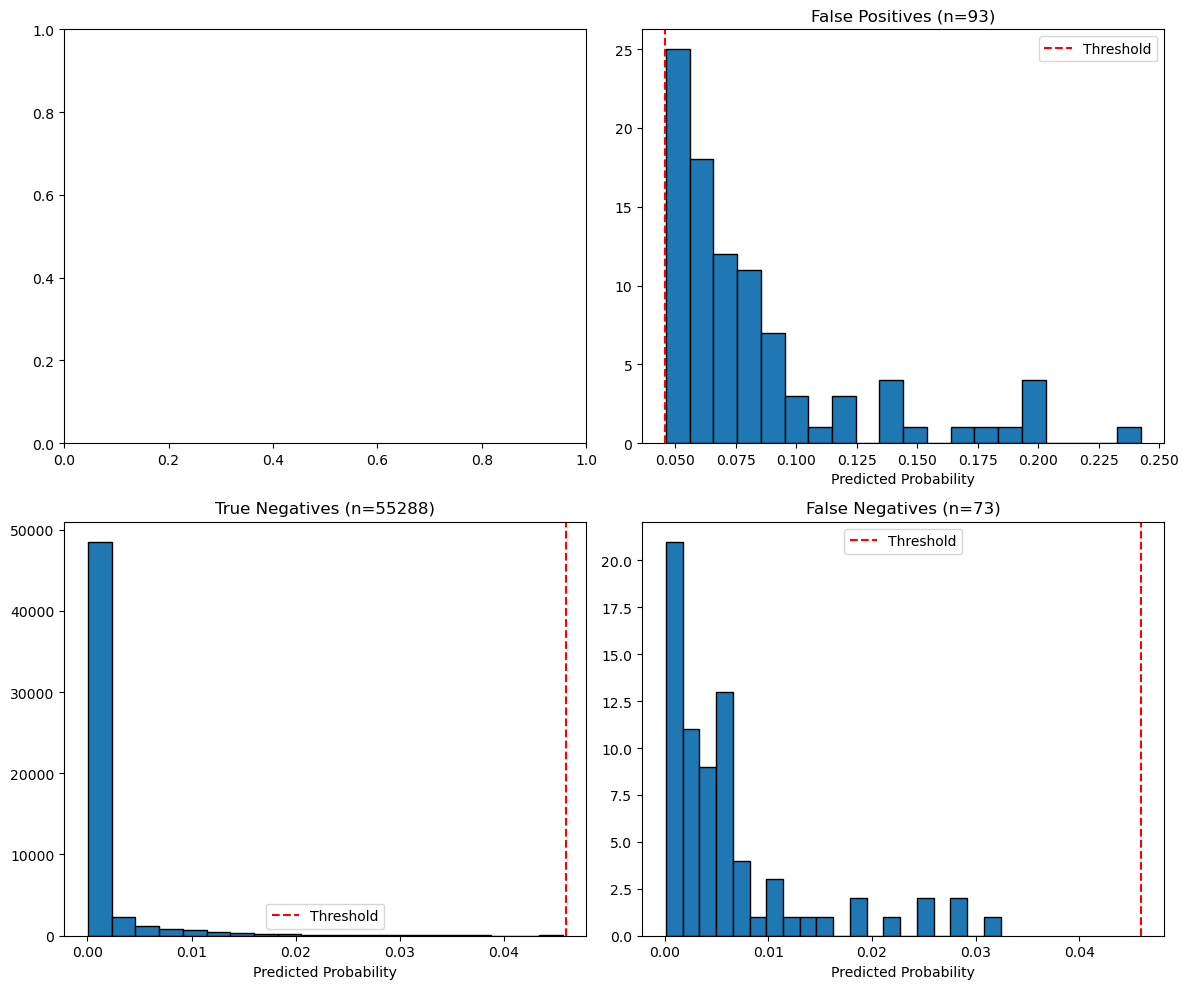


--- Feature Analysis for Errors ---

False Positives (False Alarms) - Top feature values:
STATION                   7.235377e+10
VIS_distance              1.282692e+04
SLP_sea_level_pressure    1.005591e+04
CIG_ceiling_height        1.123280e+03
ELEVATION                 3.924065e+02
TMP_air_temperature       1.900753e+02
DEW_dew_point             1.674301e+02
WND_direction_angle       1.264516e+02
WND_speed_rate            6.080645e+01
LATITUDE                  3.542881e+01
dtype: float64

False Negatives (Missed Tornadoes) - Top feature values:
STATION                   7.235385e+10
VIS_distance              1.607096e+04
CIG_ceiling_height        1.398515e+04
SLP_sea_level_pressure    1.007022e+04
ELEVATION                 3.919918e+02
TMP_air_temperature       2.576712e+02
DEW_dew_point             1.934110e+02
WND_direction_angle       1.600000e+02
WND_speed_rate            7.593151e+01
LATITUDE                  3.544723e+01
dtype: float64


In [128]:
y_pred_proba=post_model_object.test_probabilities ['final']
threshold = post_model_object.train_best_thresholds['final']

au.error_analysis(X_test,y_test,y_pred_proba,threshold=threshold, dataset_name='Validation')

### 6.2. Error Analysis Observations:

Here we notice that our model again missed high temperature and high dew tornadoes. This is likely due to a seasonal overfitting that our model has as discussed in the feature engineering section.

In [147]:
# Lets check months with tornadoes
train_val_tornadoes =(train_val_data.loc[train_val_data['TORNADO_OCCURRENCE'] == True])
train_val_torando_months = train_val_tornadoes['DATE'].dt.month_name()


test_tornadoes= (test_data.loc[test_data['TORNADO_OCCURRENCE'] == True])
test_torando_months = test_tornadoes['DATE'].dt.month_name()

print('TRAIN_VAL TORNADO MONTH COUNTS')
display(train_val_torando_months.value_counts())

print('TEST MONTH TORNADO COUNTS')
display(test_torando_months.value_counts())



TRAIN_VAL TORNADO MONTH COUNTS


DATE
May         445
April       161
October      68
March        64
June         38
August       33
November     27
February     14
December     12
July          6
January       3
Name: count, dtype: int64

TEST MONTH TORNADO COUNTS


DATE
October    37
May        12
July        9
June        9
January     6
Name: count, dtype: int64

This confirms our suspicion: there is an abnormal number of tornadoes in October 2020/2021 that were not being picked up by our model. We also confirm with a SHAP summary.

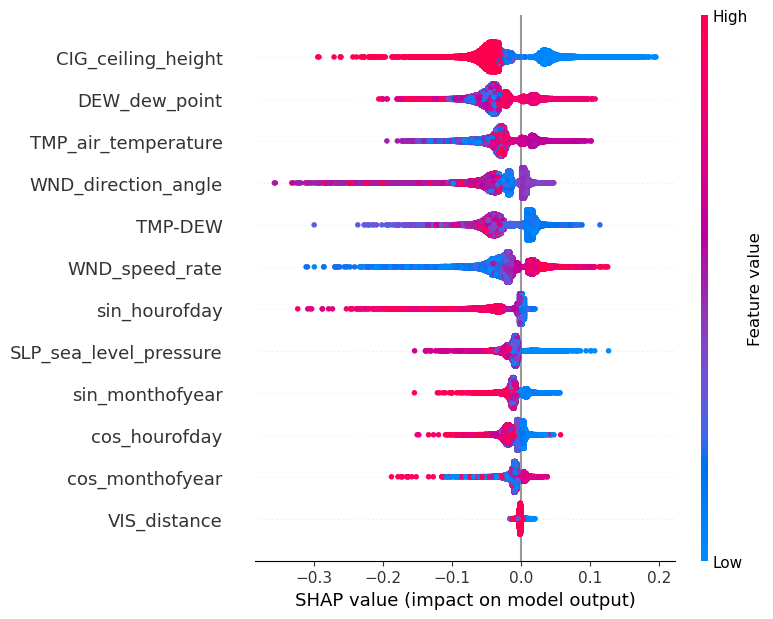

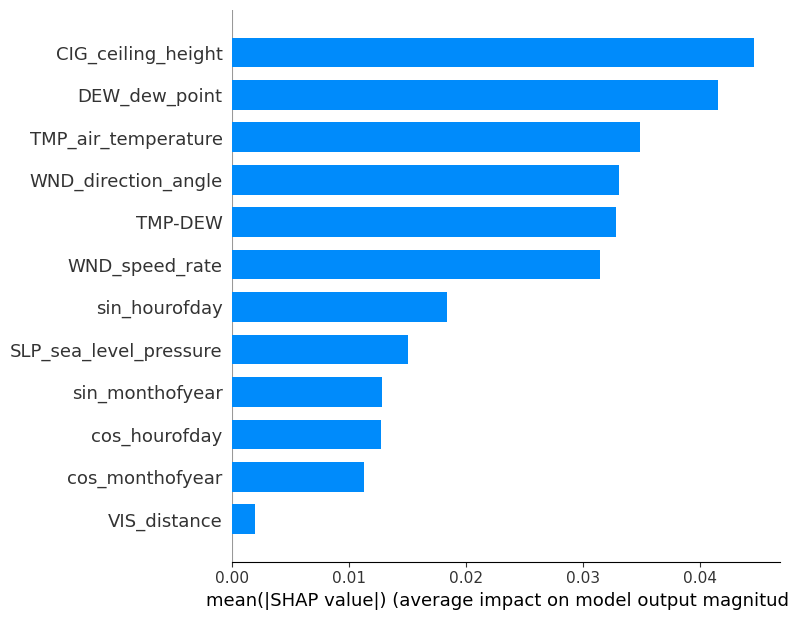

In [148]:
import shap
final_model = post_final_model

final_model.fit(X_train_val, y_train_val)
base_estimator = final_model.calibrated_classifiers_[0].estimator
preprocessing_pipeline = base_estimator[:-2]  # Everything except SMOTE and classifier
rf_classifier = base_estimator.named_steps['classifier']

# Transform validation data through preprocessing only (no SMOTE)
X_test_preprocessed = preprocessing_pipeline.transform(X_test)

# Use the fitted pipeline to get the feature names
feature_names = preprocessing_pipeline.named_steps['preprocessor'].get_feature_names_out()

explainer = shap.TreeExplainer(rf_classifier)
shap_values = explainer.shap_values(X_test_preprocessed)





shap_values_to_plot=shap_values[:, :, 1]
# Plot
shap.summary_plot(
    shap_values_to_plot, 
    X_test_preprocessed, 
    feature_names=feature_names,
    show=False
)

plt.tight_layout()
save_to = project_root/'results/final_model/shap_summary_final.png'
plt.savefig(save_to)
plt.show()

# Bar plot (mean absolute SHAP values)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_to_plot, X_test_preprocessed,feature_names=feature_names, plot_type='bar', show=False)
plt.tight_layout()
save_to = project_root/'results/final_model/shap_importance_final.png'
plt.savefig(save_to, dpi=300, bbox_inches='tight')
plt.show()

SHAP analysis reveals the model relies heavily on ceiling height and dew point, but also incorporates temporal features like hour and month of year. This moderate reliance on temporal correlations explains the strong validation performance but poor generalization to the test period. 


## 6. Future Work

1. **Investigate Temporal Distribution Shift Through Ensemble Methods:**

The significant validation→test performance drop  reveals temporal non-stationarity in tornado formation patterns. Future work should explore ensemble approaches that combine models trained on different **seasonal** periods to create more robust predictions across distributional shifts. In addition, we should also take into account the **time of day** in dealing with temporal distribution-- we saw in our EDA that Tornadoes are more common in early afternoon, but this need not always be the case.

2. **Incorporate Radar and Satellite Data**

Current features are limited to surface weather station measurements (temperature, pressure, dewpoint, ect...). Integrating Doppler radar data—particularly mesocyclone detection, hook echo patterns, and reflectivity values—could dramatically improve tornado prediction accuracy. 

